In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error, mean_squared_error, log_loss
import umap

/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


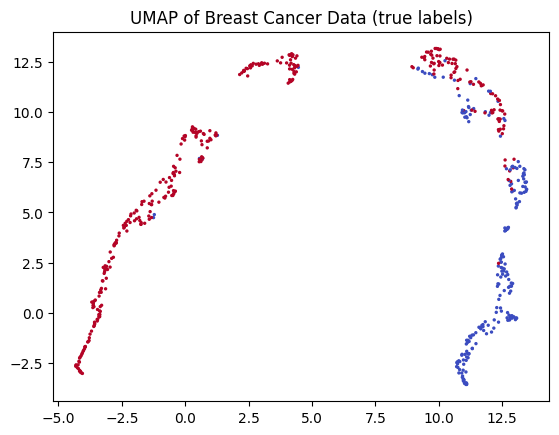

In [2]:
cancer = load_breast_cancer()
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(cancer.data)
plt.scatter(embedding[:,0], embedding[:,1], c=cancer.target, cmap='coolwarm', s=2)
plt.title("UMAP of Breast Cancer Data (true labels)")
plt.show()

In [3]:
X = cancer.data
y = cancer.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

knn_preds = knn.predict(X_test)
knn_probabilities = knn.predict_proba(X_test)      # needed for log_loss

knn_acc = accuracy_score(y_test, knn_preds)
knn_loss = log_loss(y_test, knn_probabilities)

print(f"KNN (k=5)  →  Accuracy: {knn_acc:.3f}  |  Cross‑entropy loss: {knn_loss:.3f}")

KNN (k=5)  →  Accuracy: 0.956  |  Cross‑entropy loss: 0.089


/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


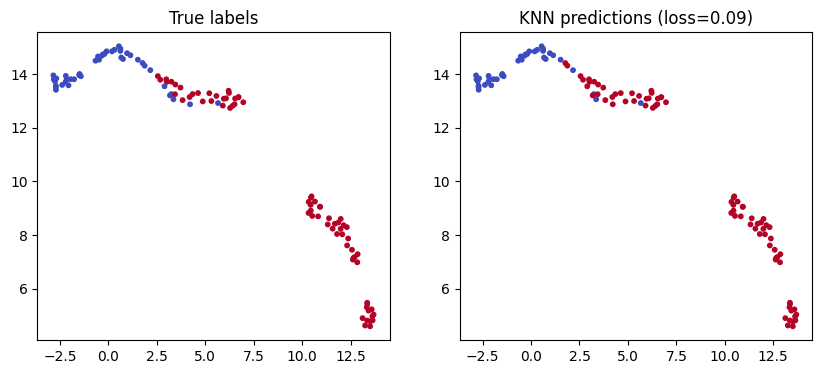

In [5]:
umap_test = umap.UMAP(random_state=42).fit_transform(X_test)
fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].scatter(umap_test[:,0], umap_test[:,1], c=y_test, cmap='coolwarm', s=10)
axes[0].set_title("True labels")
axes[1].scatter(umap_test[:,0], umap_test[:,1], c=knn_preds, cmap='coolwarm', s=10)
axes[1].set_title(f"KNN predictions (loss={knn_loss:.2f})")
plt.show()

In [6]:
for k in [1, 5, 15, 30]:
    temp = KNeighborsClassifier(n_neighbors=k)
    temp.fit(X_train, y_train)
    probs = temp.predict_proba(X_test)
    acc = accuracy_score(y_test, temp.predict(X_test))
    loss = log_loss(y_test, probs)
    print(f"k={k:2d} | accuracy={acc:.3f} | cross‑entropy loss={loss:.4f}")

k= 1 | accuracy=0.930 | cross‑entropy loss=2.5294
k= 5 | accuracy=0.956 | cross‑entropy loss=0.0892
k=15 | accuracy=0.965 | cross‑entropy loss=0.0893
k=30 | accuracy=0.947 | cross‑entropy loss=0.1153


In [7]:
logreg = LogisticRegression(max_iter=30)
logreg.fit(X_train, y_train)
logreg_preds = logreg.predict(X_test)
logreg_probabilities = logreg.predict_proba(X_test)

logreg_acc = accuracy_score(y_test, logreg_preds)
logreg_loss = log_loss(y_test, logreg_probabilities)

print(f"LogReg  →  Accuracy: {logreg_acc:.3f}  |  Cross‑entropy loss: {logreg_loss:.3f}")

LogReg  →  Accuracy: 0.939  |  Cross‑entropy loss: 0.124


/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 30 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=30).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


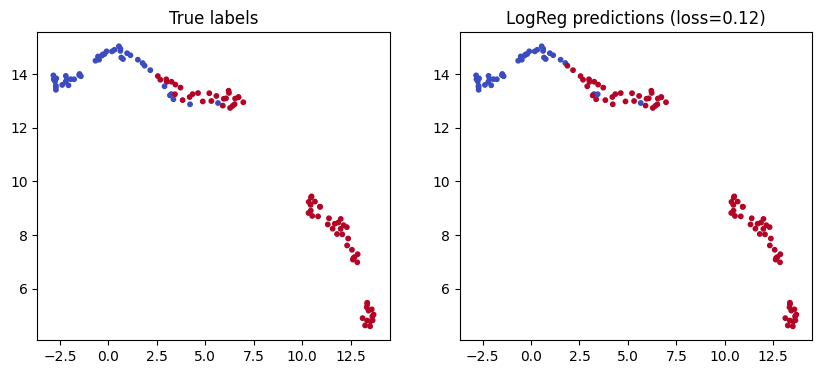

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].scatter(umap_test[:,0], umap_test[:,1], c=y_test, cmap='coolwarm', s=10)
axes[0].set_title("True labels")
axes[1].scatter(umap_test[:,0], umap_test[:,1], c=logreg_preds, cmap='coolwarm', s=10)
axes[1].set_title(f"LogReg predictions (loss={logreg_loss:.2f})")
plt.show()

/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


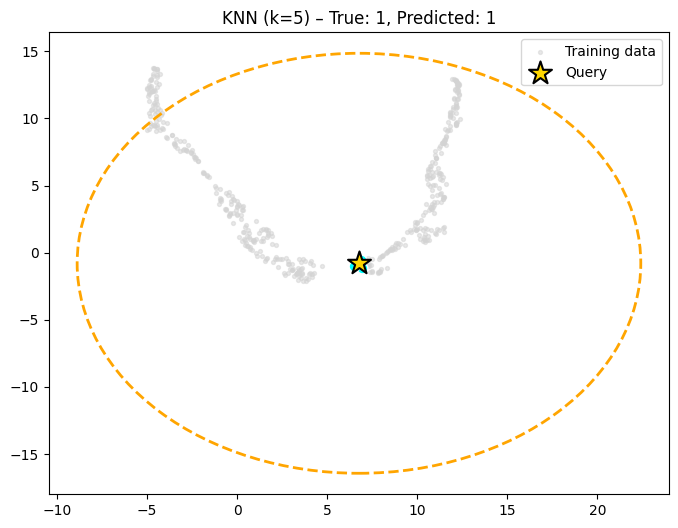

In [9]:
# Fit UMAP on the combined train+test for a shared embedding
reducer = umap.UMAP(random_state=42)
X_all = np.vstack([X_train, X_test])
reducer.fit(X_all)
X_train_umap = reducer.transform(X_train)
X_test_umap  = reducer.transform(X_test)

# Pick an interesting test point (e.g., index 10)
query_idx = 10
query_point = X_test[query_idx]
query_umap = X_test_umap[query_idx]

# Find distances to all training points
distances = np.linalg.norm(X_train - query_point, axis=1)
neighbor_idx = np.argsort(distances)[:5]   # k=5

# Plot
plt.figure(figsize=(8,6))
# Background: all training points in grey
plt.scatter(X_train_umap[:,0], X_train_umap[:,1], c='lightgrey', s=8, alpha=0.5, label='Training data')
# Nearest neighbors highlighted
for i, nidx in enumerate(neighbor_idx):
    color = 'coral' if y_train[nidx] == 0 else 'cyan'
    plt.scatter(X_train_umap[nidx,0], X_train_umap[nidx,1], color=color, s=60, edgecolor='white', linewidth=1)
# Query point
true_class = y_test[query_idx]
pred_class = knn.predict([query_point])[0]
plt.scatter(query_umap[0], query_umap[1], marker='*', s=300, color='gold', edgecolor='black', linewidth=1.5, label='Query')
# Draw a translucent circle around the query point covering the neighbors
radius = np.max(distances[neighbor_idx])
plt.gca().add_patch(plt.Circle(query_umap, radius*0.8, fill=False, edgecolor='orange', linewidth=2, linestyle='--'))
plt.title(f"KNN (k=5) – True: {true_class}, Predicted: {pred_class}")
plt.legend(loc='upper right')
plt.show()

In [10]:
print(f"KNN   accuracy: {knn_acc:.3f}  loss: {knn_loss:.3f}")
print(f"LogReg accuracy: {logreg_acc:.3f}  loss: {logreg_loss:.3f}")

KNN   accuracy: 0.956  loss: 0.089
LogReg accuracy: 0.939  loss: 0.124


In [11]:
housing = fetch_california_housing()
X, y = housing.data, housing.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

lr_mse = mean_squared_error(y_test, lr_preds)
lr_r2 = lr.score(X_test, y_test)   # R² just for context
print(f"Linear Regression  →  MSE: {lr_mse:.3f}  |  R²: {lr_r2:.3f}")

Linear Regression  →  MSE: 0.556  |  R²: 0.576


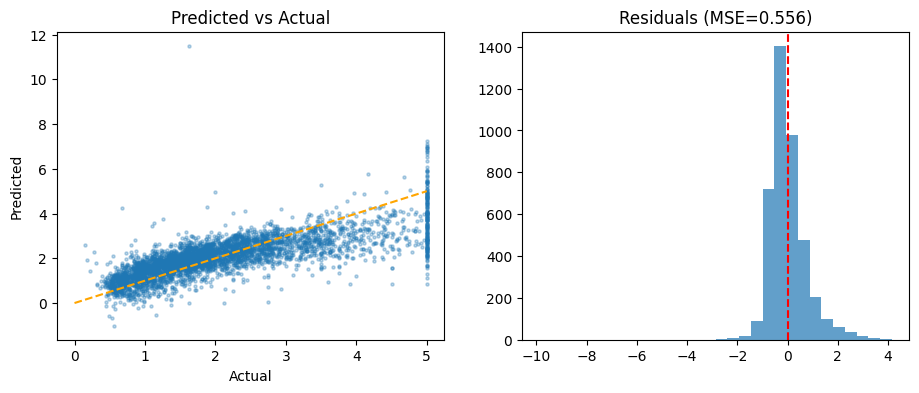

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))

# Predicted vs Actual
axes[0].scatter(y_test, lr_preds, alpha=0.3, s=5)
axes[0].plot([0,5],[0,5], '--', color='orange')
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")
axes[0].set_title("Predicted vs Actual")

# Residuals
residuals = y_test - lr_preds
axes[1].hist(residuals, bins=30, alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title(f"Residuals (MSE={lr_mse:.3f})")
plt.show()

In [14]:
from sklearn.neighbors import KNeighborsRegressor

# Baseline: predict training mean
# baseline_preds = np.full_like(y_test, y_train.mean())
# baseline_mse = mean_squared_error(y_test, baseline_preds)

# KNN regressor
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train, y_train)
knn_preds = knn_reg.predict(X_test)
knn_mse = mean_squared_error(y_test, knn_preds)

# print(f"Baseline (mean)    MSE: {baseline_mse:.3f}")
print(f"Linear Regression  MSE: {lr_mse:.3f}")
print(f"KNN Regressor      MSE: {knn_mse:.3f}")

Linear Regression  MSE: 0.556
KNN Regressor      MSE: 1.119


/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


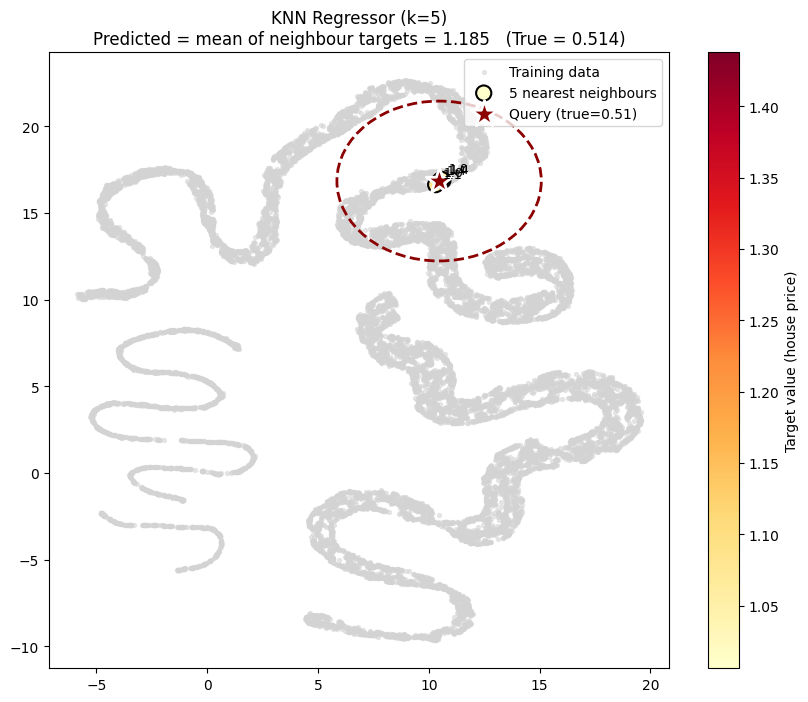

In [15]:
# 1. UMAP projection of training + test (shared space)
reducer_reg = umap.UMAP(random_state=42)
X_all_reg = np.vstack([X_train, X_test])
reducer_reg.fit(X_all_reg)
X_train_umap_reg = reducer_reg.transform(X_train)
X_test_umap_reg  = reducer_reg.transform(X_test)

# 2. Pick a query point from the test set
query_idx_reg = 25               # pick any index you like
query_point_reg = X_test[query_idx_reg]
query_umap_reg = X_test_umap_reg[query_idx_reg]

# 3. Find its 5 nearest training neighbours (Euclidean distance in original 8‑dim space)
distances_reg = np.linalg.norm(X_train - query_point_reg, axis=1)
neighbor_idx_reg = np.argsort(distances_reg)[:5]

# 4. Get the target values of those neighbours
neighbor_targets = y_train[neighbor_idx_reg]
predicted_value = knn_reg.predict([query_point_reg])[0]
true_value = y_test[query_idx_reg]

# 5. Plot
plt.figure(figsize=(10, 8))

# Background: all training points (small, grey)
plt.scatter(X_train_umap_reg[:,0], X_train_umap_reg[:,1],
            c='lightgrey', s=8, alpha=0.5, label='Training data')

# Nearest neighbours – colour by their target value (house price)
sc = plt.scatter(X_train_umap_reg[neighbor_idx_reg,0],
                 X_train_umap_reg[neighbor_idx_reg,1],
                 c=neighbor_targets, cmap='YlOrRd', s=120,
                 edgecolor='black', linewidth=1.5, label='5 nearest neighbours')

# Annotate each neighbour with its target value (optional – adds clarity)
for i, nidx in enumerate(neighbor_idx_reg):
    plt.annotate(f'{neighbor_targets[i]:.1f}',
                 (X_train_umap_reg[nidx,0], X_train_umap_reg[nidx,1]),
                 textcoords="offset points", xytext=(5,5), fontsize=9, color='black')

# Query point (star)
plt.scatter(query_umap_reg[0], query_umap_reg[1],
            marker='*', s=400, color='darkred', edgecolor='white', linewidth=2,
            label=f'Query (true={true_value:.2f})')

# Draw a translucent circle showing the neighbourhood radius
radius_reg = np.max(distances_reg[neighbor_idx_reg])
plt.gca().add_patch(plt.Circle(query_umap_reg, radius_reg*0.9, fill=False,
                               edgecolor='darkred', linewidth=2, linestyle='--'))

# Title with the prediction formula
plt.title(f"KNN Regressor (k=5)\nPredicted = mean of neighbour targets = {predicted_value:.3f}   (True = {true_value:.3f})",
          fontsize=12)
plt.colorbar(sc, label='Target value (house price)')
plt.legend(loc='upper right')
plt.show()

In [16]:
X = cancer.data  # no y

In [17]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X)

# Compare with true labels (which we pretend we don't have)
pd.crosstab(cancer.target, clusters)

col_0,0,1
row_0,,
0,130,82
1,1,356


/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


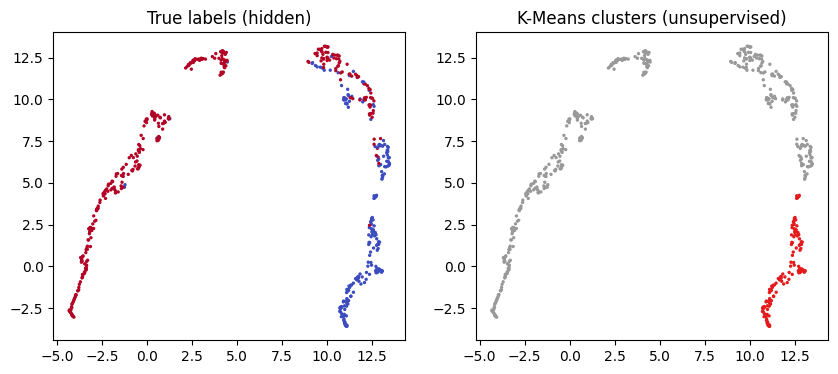

In [18]:
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X)
fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].scatter(embedding[:,0], embedding[:,1], c=cancer.target, cmap='coolwarm', s=2)
axes[0].set_title("True labels (hidden)")
axes[1].scatter(embedding[:,0], embedding[:,1], c=clusters, cmap='Set1', s=2)
axes[1].set_title("K-Means clusters (unsupervised)")
plt.show()

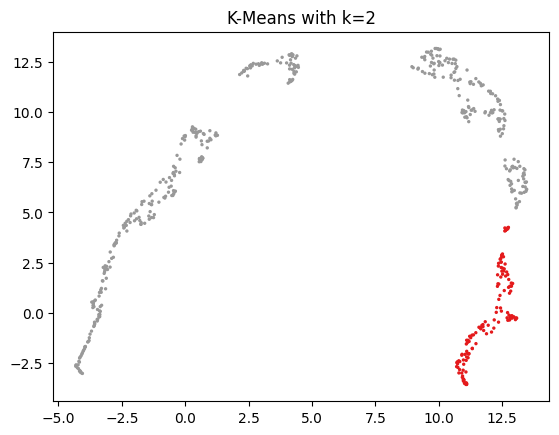

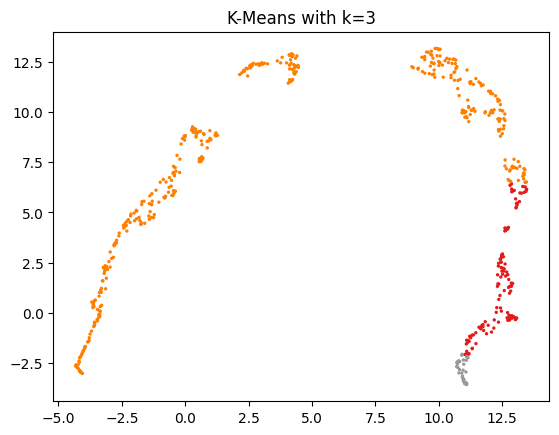

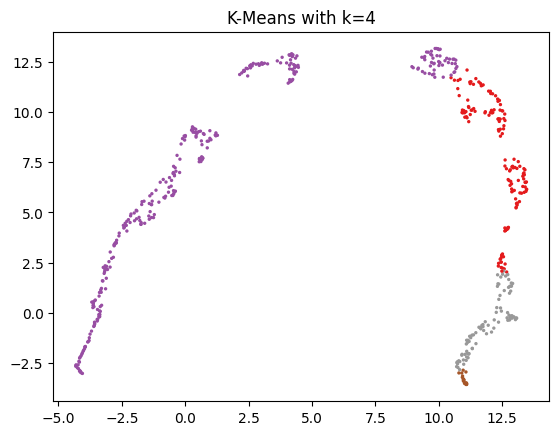

In [19]:
for k in [2, 3, 4]:
    temp = KMeans(n_clusters=k, random_state=42)
    labs = temp.fit_predict(X)
    plt.figure()
    plt.scatter(embedding[:,0], embedding[:,1], c=labs, cmap='Set1', s=2)
    plt.title(f"K-Means with k={k}")
    plt.show()